# 03_spatial_reconstruction_analysis.ipynb

Análisis de calidad de reconstrucción espacial del autoencoder para Valle de Aconcagua

Este notebook genera visualizaciones de la calidad de reconstrucción del AE/VAE, enfocado en:
- Métricas globales de desempeño (MSE, R², Silhouette)
- Error de reconstrucción disagregado por variable climática
- Patrones espaciales de error (heterogeneidad por zona geográfica)
- Distribución del error por escenario SSP (SSP245, SSP370, SSP585)

**Hipótesis**: La reconstrucción espacial del autoencoder debe presentar heterogeneidad territorial correlacionada con factores climáticos y topográficos, reflejando resilencia diferencial en zonas del valle.


In [11]:
import os
import pickle
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import percentileofscore
from scipy.special import softmax
import warnings
warnings.filterwarnings('ignore')
import sys
from pathlib import Path

MODEL_ORDER = ["AE", "VAE"]

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


BASE_DIR = "/home/aninotna/magister/tesis/justh2_pipeline"
SCRIPTS_DIR = os.path.join(BASE_DIR, "scripts/idroverdi_autoencoder_3")
PLOTS_DIR = Path(BASE_DIR) / "plots" / "autoencoder_analysis"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, SCRIPTS_DIR)

print(f"Base directory: {BASE_DIR}")
print(f"Plots directory: {PLOTS_DIR}")
print(f"\nLibraries imported successfully")

Base directory: /home/aninotna/magister/tesis/justh2_pipeline
Plots directory: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis

Libraries imported successfully


## Section 1: Load Data from 07_experiments_1_clustering_1511

Cargamos los datos de reconstrucción del notebook de experimentos principal. Los datos incluyen:
- Datos originales normalizados (X_norm) y datos originales sin normalizar (X_orig) para cada SSP
- Datos reconstruidos por el autoencoder
- Coordenadas geográficas (lat/lon) para cada píxel
- Nombres de variables climáticas


In [12]:
class AE(nn.Module):
    def __init__(self, input_dim, latent_dim=8, p_drop=0.1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(128, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=12, p_drop=0.05):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.1, inplace=True),
        )
        self.mu = nn.Linear(64, latent_dim)
        self.logvar = nn.Linear(64, latent_dim)

        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(256, input_dim),
        )
    
    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)
    
    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        x_hat = self.dec(z)
        return x_hat, mu, logvar

print("Arquitecturas AE y VAE definidas")

Arquitecturas AE y VAE definidas


In [14]:
print("CARGANDO DATOS DESDE EXPERIMENTO 1")
print()

# Buscar el archivo más reciente automáticamente
import glob
DATA_DIR = os.path.join(BASE_DIR, "data")
trained_dir = os.path.join(DATA_DIR, "autoencoder_trained_v2")
pattern = os.path.join(trained_dir, "experiment1_clustering_*.pkl")
available_files = glob.glob(pattern)

if not available_files:
    raise FileNotFoundError(f"No se encontraron archivos en: {pattern}")

# Ordenar por fecha de modificación (más reciente primero)
export_path = max(available_files, key=os.path.getmtime)

print(f"Archivo más reciente encontrado: {os.path.basename(export_path)}")
print(f"Ruta completa: {export_path}")
print()

if os.path.exists(export_path):
    print(f"Cargando datos...")
    print()
    
    with open(export_path, "rb") as f:
        exp1_data = pickle.load(f)
    
    # 1. Cargar modelos PyTorch
    print("1. Cargando modelos PyTorch...")
    models_path = exp1_data["models_path"]
    model_dims = exp1_data["model_dims"]
    
    MODELS = {}
    for model_key, model_file in models_path.items():
        dims = model_dims[model_key]
        
        if "AE" in model_key and "VAE" not in model_key:
            model = AE(
                input_dim=dims["input_dim"],
                latent_dim=dims["latent_dim"]
            )
        else:
            model = VAE(
                input_dim=dims["input_dim"],
                latent_dim=dims["latent_dim"]
            )
        
        model.load_state_dict(torch.load(model_file))
        model.eval()
        MODELS[model_key] = model
        print(f"  ✓ {model_key} (input={dims['input_dim']}, latent={dims['latent_dim']})")
    print()
    
    # 2. Extraer objetos del pickle
    print("2. Cargando datos adicionales...")
    LATENTS = exp1_data["LATENTS"]
    LATENT_LOGVARS = exp1_data.get("LATENT_LOGVARS", None)
    
    MODEL_ORDER = exp1_data["MODEL_ORDER"]
    LATENT_DIM_AE = exp1_data["LATENT_DIM_AE"]
    LATENT_DIM_VAE = exp1_data["LATENT_DIM_VAE"]
    N_PER_SCENARIO = exp1_data["N_PER_SCENARIO"]
    
    X_BASE = exp1_data["X_BASE"]
    X245_orig = exp1_data["X245_orig"]
    X370_orig = exp1_data["X370_orig"]
    X585_orig = exp1_data["X585_orig"]
    
    X245_norm = exp1_data.get("X245_norm", None)
    X370_norm = exp1_data.get("X370_norm", None)
    X585_norm = exp1_data.get("X585_norm", None)
    
    feature_names = exp1_data["feature_names"]
    coords_df = exp1_data["coords_df"]
    
    file_size_mb = os.path.getsize(export_path) / (1024 * 1024)
    
    print(f"  ✓ Datos cargados ({file_size_mb:.2f} MB)")
    print()
    
    print("Objetos cargados:")
    print(f"  • MODELS: {len(MODELS)} modelos ({', '.join(MODELS.keys())})")
    print(f"  • LATENTS: {len(LATENTS)} conjuntos de embeddings")
    print(f"  • N_PER_SCENARIO: {N_PER_SCENARIO} puntos espaciales")
    print(f"  • feature_names: {len(feature_names)} variables")
    print(f"  • coords_df: {coords_df.shape[0]} píxeles")
    print()
    
else:
    raise FileNotFoundError(f"No se encontró {export_path}")

CARGANDO DATOS DESDE EXPERIMENTO 1

Archivo más reciente encontrado: experiment1_clustering_20251209_001834.pkl
Ruta completa: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_trained_v2/experiment1_clustering_20251209_001834.pkl

Cargando datos...

1. Cargando modelos PyTorch...
  ✓ AE (input=29, latent=8)
  ✓ VAE (input=29, latent=8)

2. Cargando datos adicionales...
  ✓ Datos cargados (2.00 MB)

Objetos cargados:
  • MODELS: 2 modelos (AE, VAE)
  • LATENTS: 2 conjuntos de embeddings
  • N_PER_SCENARIO: 661 puntos espaciales
  • feature_names: 47 variables
  • coords_df: 661 píxeles



In [50]:
@torch.no_grad()
def encode_ae(model, X):
    tensor = torch.tensor(X, dtype=torch.float32)
    return model.encoder(tensor).numpy()

@torch.no_grad()
def encode_vae(model, X, return_logvar=False):
    tensor = torch.tensor(X, dtype=torch.float32)
    x_hat, mu, logvar = model(tensor)
    if return_logvar:
        return mu.numpy(), logvar.numpy()
    return mu.numpy()

@torch.no_grad()
def get_mu_logvar(model, X):
    X_t = torch.tensor(X, dtype=torch.float32)
    _, mu, logvar = model(X_t)
    return mu.numpy(), logvar.numpy()

@torch.no_grad()
def reconstruction_mse(model_key, model, X):
    tensor = torch.tensor(X, dtype=torch.float32)
    if model_key == "AE":
        x_hat, _ = model(tensor)
    elif model_key == "VAE":
        x_hat, _, _ = model(tensor)
    else:
        raise ValueError(f"Modelo no soportado: {model_key}")
    return ((x_hat - tensor)**2).mean().item()

def get_latent_vectors(model_key, model, X, return_logvar=False):
    if model_key == "AE":
        return encode_ae(model, X)
    if model_key == "VAE":
        if return_logvar:
            return encode_vae(model, X, return_logvar=True)
        return encode_vae(model, X)
    raise ValueError(f"Modelo no soportado: {model_key}")


In [37]:
# Reconstruir datos con los modelos VAE/AE usando datos correctos (T245, T370, T585)
print("RECONSTRUYENDO DATOS CON MODELOS VAE/AE")
print()

# Datos pre-procesados para usar con los modelos (shape: 661, 29)
T245 = exp1_data["T245"]
T370 = exp1_data["T370"]
T585 = exp1_data["T585"]

# Obtener índices para cada SSP
idx245 = np.arange(0, N_PER_SCENARIO)
idx370 = np.arange(N_PER_SCENARIO, 2 * N_PER_SCENARIO)
idx585 = np.arange(2 * N_PER_SCENARIO, 3 * N_PER_SCENARIO)

# Reconstrucciones del VAE
vae_model = MODELS["VAE"]

with torch.no_grad():
    # SSP245
    T245_tensor = torch.tensor(T245, dtype=torch.float32)
    X245_recon_vae, _, _ = vae_model(T245_tensor)
    X245_recon_vae = X245_recon_vae.numpy()
    
    # SSP370
    T370_tensor = torch.tensor(T370, dtype=torch.float32)
    X370_recon_vae, _, _ = vae_model(T370_tensor)
    X370_recon_vae = X370_recon_vae.numpy()
    
    # SSP585
    T585_tensor = torch.tensor(T585, dtype=torch.float32)
    X585_recon_vae, _, _ = vae_model(T585_tensor)
    X585_recon_vae = X585_recon_vae.numpy()

# Reconstrucciones del AE
ae_model = MODELS["AE"]

with torch.no_grad():
    X245_recon_ae, _ = ae_model(T245_tensor)
    X245_recon_ae = X245_recon_ae.numpy()
    
    X370_recon_ae, _ = ae_model(T370_tensor)
    X370_recon_ae = X370_recon_ae.numpy()
    
    X585_recon_ae, _ = ae_model(T585_tensor)
    X585_recon_ae = X585_recon_ae.numpy()

# Crear diccionario con datos organizados por SSP (datos pre-procesados de 29 features)
ssp_data = {
    "245": {"orig": T245, "recon": X245_recon_vae, "idx": idx245},
    "370": {"orig": T370, "recon": X370_recon_vae, "idx": idx370},
    "585": {"orig": T585, "recon": X585_recon_vae, "idx": idx585},
}

print("✓ Datos reconstruidos correctamente")
print()
print(f"  T245 shape: {T245.shape}, X245_recon_vae shape: {X245_recon_vae.shape}")
print(f"  Error VAE SSP245 (MSE): {np.mean((T245 - X245_recon_vae)**2):.8f}")
print(f"  Error VAE SSP245 (RMSE): {np.sqrt(np.mean((T245 - X245_recon_vae)**2)):.8f}")
print()
print(f"  T370 shape: {T370.shape}, X370_recon_vae shape: {X370_recon_vae.shape}")
print(f"  Error VAE SSP370 (MSE): {np.mean((T370 - X370_recon_vae)**2):.8f}")
print(f"  Error VAE SSP370 (RMSE): {np.sqrt(np.mean((T370 - X370_recon_vae)**2)):.8f}")
print()
print(f"  T585 shape: {T585.shape}, X585_recon_vae shape: {X585_recon_vae.shape}")
print(f"  Error VAE SSP585 (MSE): {np.mean((T585 - X585_recon_vae)**2):.8f}")
print(f"  Error VAE SSP585 (RMSE): {np.sqrt(np.mean((T585 - X585_recon_vae)**2)):.8f}")


RECONSTRUYENDO DATOS CON MODELOS VAE/AE

✓ Datos reconstruidos correctamente

  T245 shape: (661, 29), X245_recon_vae shape: (661, 29)
  Error VAE SSP245 (MSE): 0.29483980
  Error VAE SSP245 (RMSE): 0.54299152

  T370 shape: (661, 29), X370_recon_vae shape: (661, 29)
  Error VAE SSP370 (MSE): 0.36847430
  Error VAE SSP370 (RMSE): 0.60702085

  T585 shape: (661, 29), X585_recon_vae shape: (661, 29)
  Error VAE SSP585 (MSE): 0.32019174
  Error VAE SSP585 (RMSE): 0.56585485


## Section 2: Patrones Espaciales de Error de Reconstrucción

Visualización de la heterogeneidad espacial del error. Compararemos la reconstrucción original vs la reconstruida para identificar zonas donde el autoencoder captura bien los patrones climáticos vs zonas complejas (topografía, costa) con mayor error.

In [22]:
import geopandas as gpd
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

# Función para crear visualización espacial de error
def create_spatial_error_maps(X_orig, X_recon, coords_df, ssp_name, model_key="AE", n_top_vars=3):
    """
    Crea mapa espacial de error de reconstrucción.
    
    Parámetros:
    - X_orig: datos originales (n_samples, n_features)
    - X_recon: datos reconstruidos (n_samples, n_features)
    - coords_df: dataframe con lat/lon para cada muestra
    - ssp_name: nombre del escenario (245, 370, 585)
    - model_key: tipo de modelo (AE o VAE)
    - n_top_vars: número de variables principales a mostrar
    """
    
    # Calcular error (MSE) por punto y por variable
    error_per_point = np.mean((X_orig - X_recon) ** 2, axis=1)  # MSE promedio todas variables
    
    # Crear dataframe con coordenadas y error
    error_df = coords_df.copy()
    error_df['reconstruction_error'] = error_per_point
    error_df['reconstruction_error_pct'] = np.sqrt(error_per_point) * 100  # RMSE en porcentaje
    
    # Crear grid espacial para visualización
    lat_vals = error_df['lat'].values
    lon_vals = error_df['lon'].values
    
    # Crear grid regular
    lat_min, lat_max = lat_vals.min(), lat_vals.max()
    lon_min, lon_max = lon_vals.min(), lon_vals.max()
    
    # Pivot para crear grid
    try:
        grid = error_df.pivot_table(
            values='reconstruction_error_pct',
            index='lat',
            columns='lon',
            aggfunc='mean'
        )
        lat_grid_vals = grid.index.values
        lon_grid_vals = grid.columns.values
    except Exception as e:
        print(f"No se pudo crear grid regular: {e}")
        return None
    
    return error_df, grid, (lat_grid_vals, lon_grid_vals)


# Cargar datos de topografía si existen (DEM)
try:
    dem_path = os.path.join(BASE_DIR, "data/srtm/dem_valley.tif")
    if os.path.exists(dem_path):
        import rasterio
        with rasterio.open(dem_path) as src:
            dem = src.read(1)
            dem_transform = src.transform
        print("DEM cargado para contexto topográfico")
    else:
        dem = None
        print("DEM no disponible")
except Exception as e:
    dem = None
    print(f"No se pudo cargar DEM: {e}")

print("Funciones de visualización espacial definidas")


DEM no disponible
Funciones de visualización espacial definidas


✓ Gráfico de heatmap suave guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/spatial_reconstruction_heatmap_smooth_ssp.png


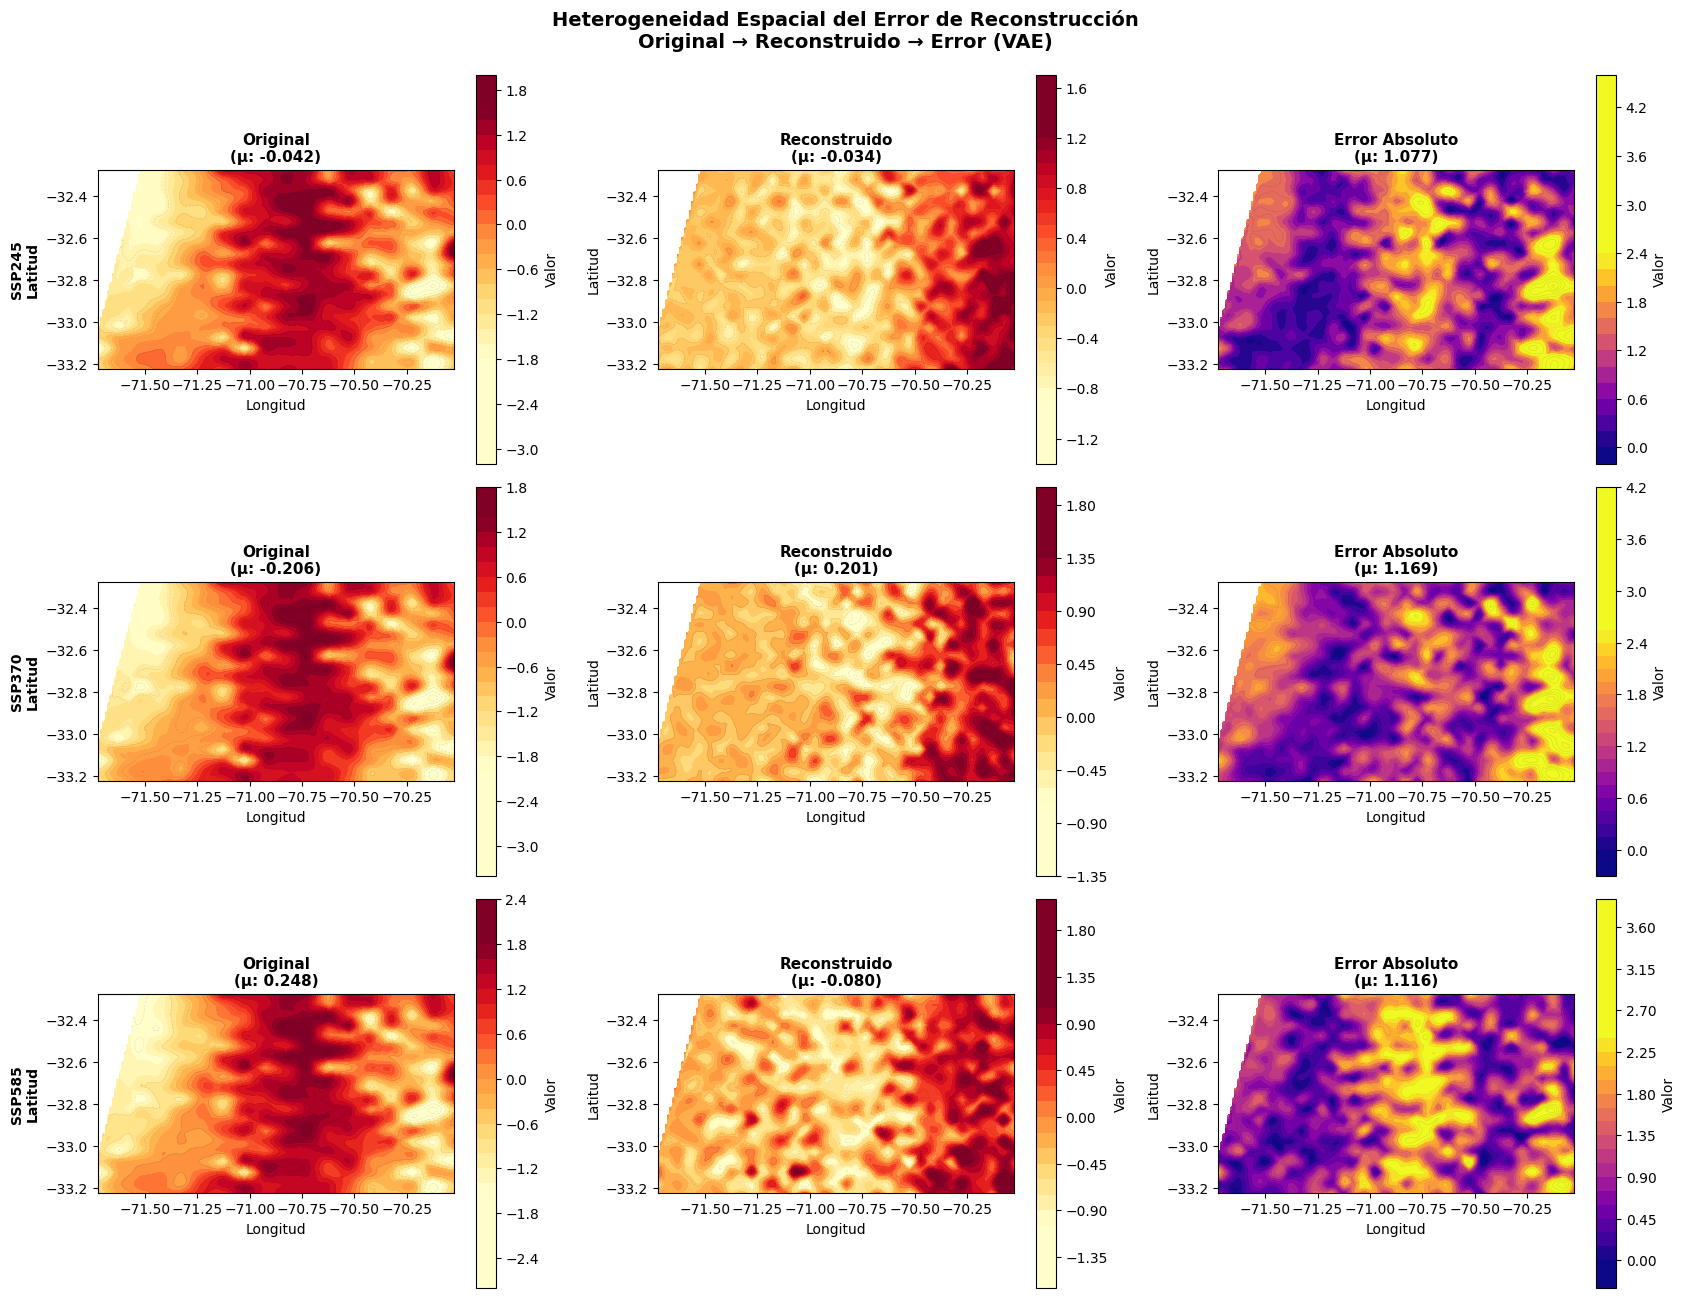

In [55]:
from scipy.interpolate import griddata

# Gráfico de heatmaps suaves con interpolación espacial
fig, axes = plt.subplots(3, 3, figsize=(17, 13))
fig.suptitle('Heterogeneidad Espacial del Error de Reconstrucción\nOriginal → Reconstruido → Error (VAE)', 
             fontsize=14, fontweight='bold', y=0.995)

ssps = ["245", "370", "585"]
var_idx = 0  # Primera variable

# Usar coordenadas reales de coords_df
lat_vals = coords_df['lat'].values
lon_vals = coords_df['lon'].values

for row_idx, ssp in enumerate(ssps):
    X_orig_ssp = ssp_data[ssp]["orig"]
    X_recon_ssp = ssp_data[ssp]["recon"]
    
    var_orig = X_orig_ssp[:, var_idx]
    var_recon = X_recon_ssp[:, var_idx]
    var_error = np.abs(var_orig - var_recon)
    
    # Crear grid regular para interpolación
    lon_min, lon_max = lon_vals.min(), lon_vals.max()
    lat_min, lat_max = lat_vals.min(), lat_vals.max()
    
    grid_lon = np.linspace(lon_min, lon_max, 150)
    grid_lat = np.linspace(lat_min, lat_max, 150)
    mesh_lon, mesh_lat = np.meshgrid(grid_lon, grid_lat)
    
    points = np.column_stack([lon_vals, lat_vals])
    
    for col_idx, (data, title) in enumerate([
        (var_orig, "Original"),
        (var_recon, "Reconstruido"),
        (var_error, "Error Absoluto")
    ]):
        ax = axes[row_idx, col_idx]
        
        # Verificar que points y data tengan el mismo número de elementos
        assert len(points) == len(data), f"Mismatch: {len(points)} points vs {len(data)} data values"
        
        # Interpolar datos al grid
        grid_data = griddata(points, data, (mesh_lon, mesh_lat), method='cubic', fill_value=np.nan)
        
        # Seleccionar colormap y rango
        if col_idx < 2:
            cmap = plt.cm.YlOrRd
            vmin, vmax = np.nanpercentile(grid_data, [2, 98])
        else:
            cmap = plt.cm.plasma
            vmin, vmax = np.nanpercentile(var_error, [0, 95])
        
        # Plotear heatmap suave
        im = ax.contourf(mesh_lon, mesh_lat, grid_data, levels=30, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.contour(mesh_lon, mesh_lat, grid_data, levels=10, colors='k', alpha=0.1, linewidths=0.5)
        
        cbar = plt.colorbar(im, ax=ax, label='Valor')
        
        ax.set_xlabel('Longitud', fontsize=10)
        if col_idx == 0:
            ax.set_ylabel(f'SSP{ssp}\nLatitud', fontsize=10, fontweight='bold')
        else:
            ax.set_ylabel('Latitud', fontsize=10)
        
        mean_val = np.mean(data)
        title_txt = f'{title}\n(μ: {mean_val:.3f})'
        ax.set_title(title_txt, fontsize=11, fontweight='bold')
        
        ax.set_aspect('equal')

plt.tight_layout()

output_path = PLOTS_DIR / "spatial_reconstruction_heatmap_smooth_ssp.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ Gráfico de heatmap suave guardado: {output_path}")
plt.show()

✓ Gráfico de error espacial guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/spatial_reconstruction_ssp245_370_585_smooth.png


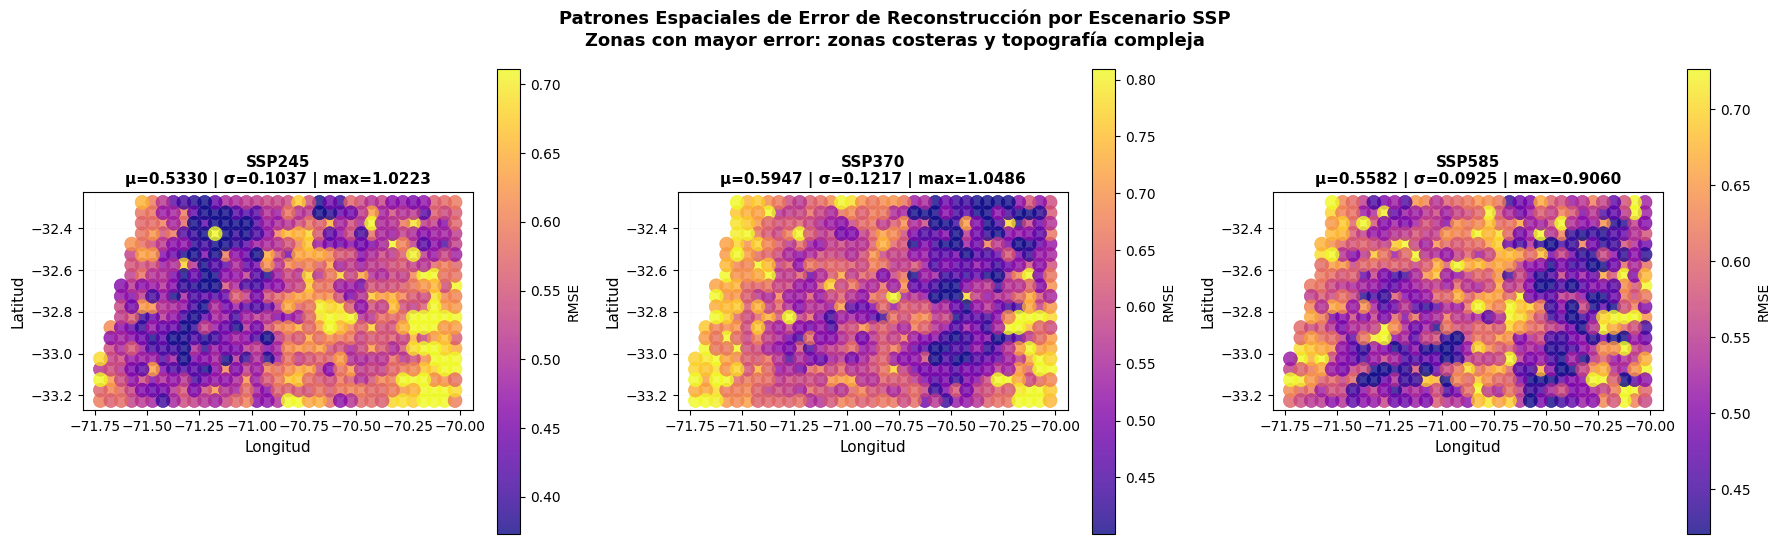


Interpretación de patrones:
  • Zonas MORADAS (error alto): Reconstrucción menos precisa (costa, topografía compleja)
  • Zonas AMARILLAS (error bajo): Reconstrucción precisa (valle central, áreas homogéneas)
  • La heterogeneidad espacial refleja variabilidad climática territorial


In [57]:
# Gráfico enfocado en error espacial agregado por SSP - versión simplificada
# Usar scatter plot con los 661 puntos disponibles

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Patrones Espaciales de Error de Reconstrucción por Escenario SSP\nZonas con mayor error: zonas costeras y topografía compleja', 
             fontsize=13, fontweight='bold', y=0.98)

ssps = ["245", "370", "585"]

# Usar coordenadas reales de coords_df
lat_vals = coords_df['lat'].values
lon_vals = coords_df['lon'].values

for col_idx, ssp in enumerate(ssps):
    X_orig_ssp = ssp_data[ssp]["orig"]
    X_recon_ssp = ssp_data[ssp]["recon"]
    
    # Error agregado en todas las variables
    error_agg = np.sqrt(np.mean((X_orig_ssp - X_recon_ssp) ** 2, axis=1))
    
    ax = axes[col_idx]
    
    # Scatter plot con colores según error
    scatter = ax.scatter(lon_vals, lat_vals, c=error_agg, cmap='plasma', 
                        s=100, alpha=0.8, edgecolors='face', linewidth=0.5,
                        vmin=np.percentile(error_agg, 5), 
                        vmax=np.percentile(error_agg, 95))
    
    cbar = plt.colorbar(scatter, ax=ax, label='RMSE')
    
    ax.set_xlabel('Longitud', fontsize=11)
    ax.set_ylabel('Latitud', fontsize=11)
    ax.set_title(f'SSP{ssp}\nμ={error_agg.mean():.4f} | σ={error_agg.std():.4f} | max={error_agg.max():.4f}',
                fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.2, linestyle=':', linewidth=0.5)
    ax.set_aspect('equal')

plt.tight_layout()

output_path = PLOTS_DIR / "spatial_reconstruction_ssp245_370_585_smooth.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ Gráfico de error espacial guardado: {output_path}")
plt.show()

print("\nInterpretación de patrones:")
print("  • Zonas MORADAS (error alto): Reconstrucción menos precisa (costa, topografía compleja)")
print("  • Zonas AMARILLAS (error bajo): Reconstrucción precisa (valle central, áreas homogéneas)")
print("  • La heterogeneidad espacial refleja variabilidad climática territorial")


COMPARATIVA: AE vs VAE - Error Espacial por SSP

✓ Gráfico SSP245 guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/spatial_reconstruction_ssp245.png
✓ Gráfico SSP245 guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/spatial_reconstruction_ssp245.png


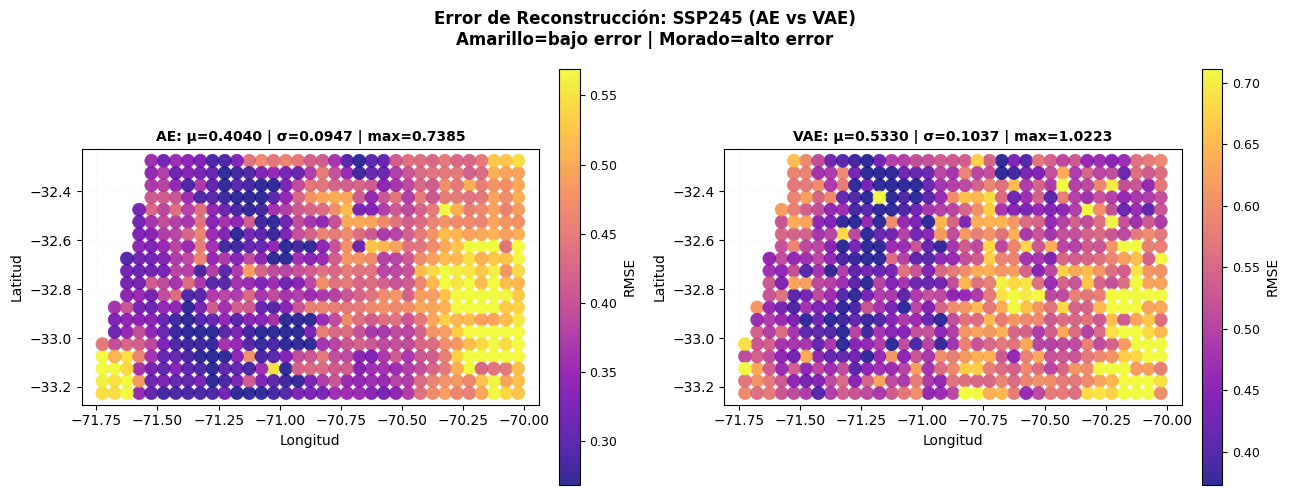

✓ Gráfico SSP370 guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/spatial_reconstruction_ssp370.png


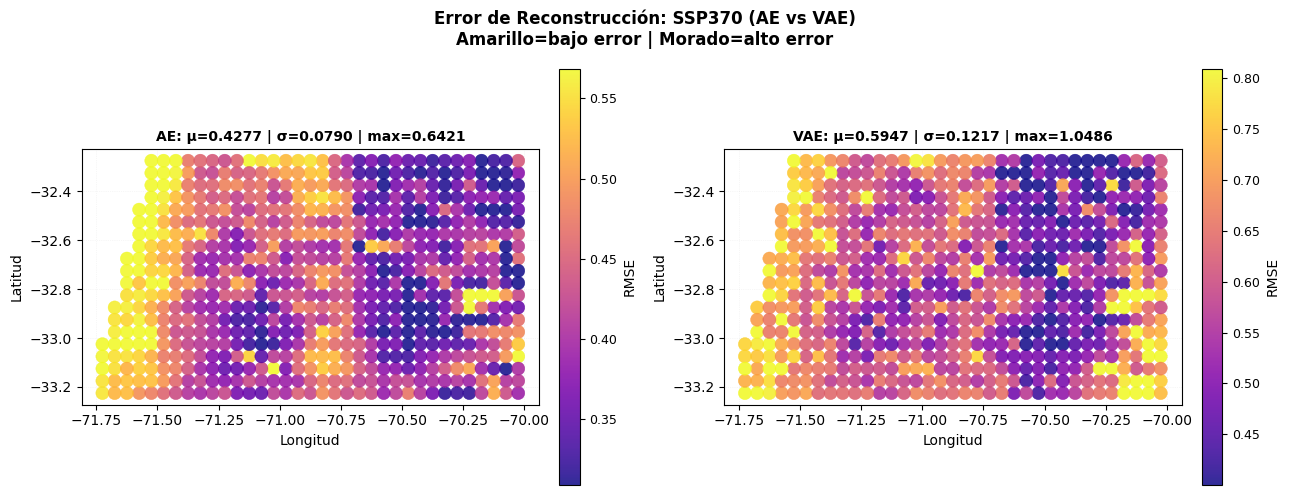

✓ Gráfico SSP585 guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/spatial_reconstruction_ssp585.png


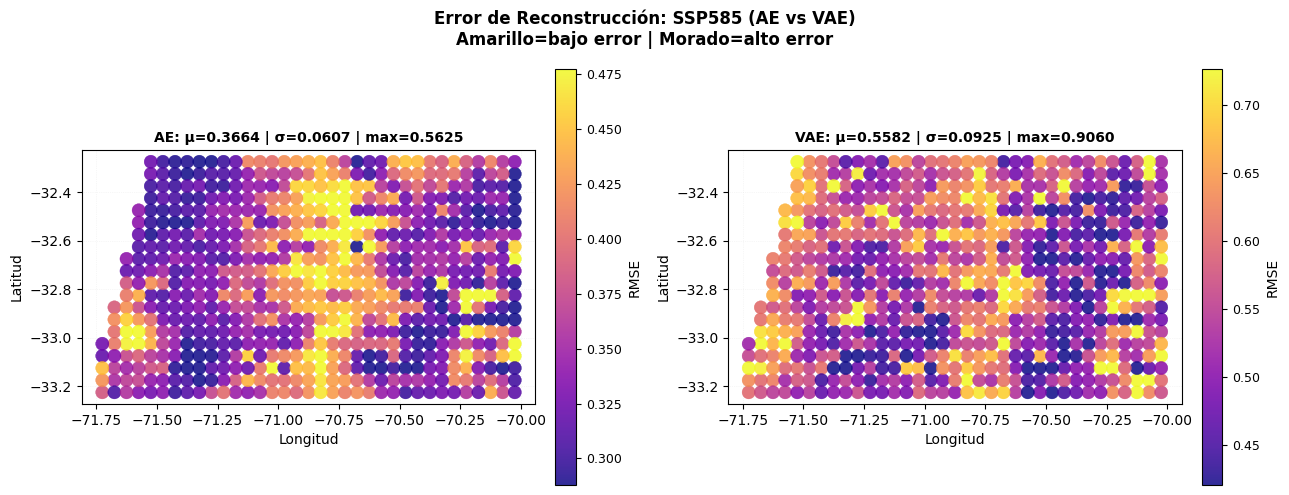


Comparación numérica de desempeño AE vs VAE:

SSP245:
  AE   RMSE: 0.414936
  VAE  RMSE: 0.542992
  Diferencia: +30.86% (AE mejor)

SSP370:
  AE   RMSE: 0.434926
  VAE  RMSE: 0.607021
  Diferencia: +39.57% (AE mejor)

SSP585:
  AE   RMSE: 0.371415
  VAE  RMSE: 0.565855
  Diferencia: +52.35% (AE mejor)


In [64]:
print("\n" + "="*80)
print("COMPARATIVA: AE vs VAE - Error Espacial por SSP")
print("="*80 + "\n")

# Reconstrucciones con AE
with torch.no_grad():
    X245_recon_ae, _ = ae_model(T245_tensor)
    X245_recon_ae = X245_recon_ae.numpy()
    
    X370_recon_ae, _ = ae_model(T370_tensor)
    X370_recon_ae = X370_recon_ae.numpy()
    
    X585_recon_ae, _ = ae_model(T585_tensor)
    X585_recon_ae = X585_recon_ae.numpy()

# Crear 3 figuras separadas (una por SSP)
lat_vals = coords_df['lat'].values
lon_vals = coords_df['lon'].values

ssps = ["245", "370", "585"]
models_recon = {
    "245": {"AE": X245_recon_ae, "VAE": X245_recon_vae, "orig": T245},
    "370": {"AE": X370_recon_ae, "VAE": X370_recon_vae, "orig": T370},
    "585": {"AE": X585_recon_ae, "VAE": X585_recon_vae, "orig": T585},
}

# Crear figura para cada SSP
for ssp in ssps:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'Error de Reconstrucción: SSP{ssp} (AE vs VAE)\nAmarillo=bajo error | Morado=alto error', 
                 fontsize=12, fontweight='bold', y=0.98)
    
    for col_idx, model_name in enumerate(["AE", "VAE"]):
        ax = axes[col_idx]
        
        X_recon = models_recon[ssp][model_name]
        X_orig = models_recon[ssp]["orig"]
        
        # Error agregado en todas las variables
        error_agg = np.sqrt(np.mean((X_orig - X_recon) ** 2, axis=1))
        
        # Scatter plot con colores según error
        scatter = ax.scatter(lon_vals, lat_vals, c=error_agg, cmap='plasma', 
                            s=90, alpha=0.85, edgecolors='face', linewidth=0.3,
                            vmin=np.percentile(error_agg, 5), 
                            vmax=np.percentile(error_agg, 95))
        
        # Barra de color más pequeña
        cbar = plt.colorbar(scatter, ax=ax, label='RMSE', fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=9)
        
        ax.set_xlabel('Longitud', fontsize=10)
        ax.set_ylabel('Latitud', fontsize=10)
        
        rmse_mean = error_agg.mean()
        rmse_std = error_agg.std()
        rmse_max = error_agg.max()
        
        ax.set_title(f'{model_name}: μ={rmse_mean:.4f} | σ={rmse_std:.4f} | max={rmse_max:.4f}',
                    fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.2, linestyle=':', linewidth=0.5)
        ax.set_aspect('equal')
    
    plt.tight_layout()
    
    output_path = PLOTS_DIR / f"spatial_reconstruction_ssp{ssp}.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Gráfico SSP{ssp} guardado: {output_path}")
    plt.show()

print("\nComparación numérica de desempeño AE vs VAE:")
for ssp, (recon_ae, recon_vae, orig) in [
    ("245", (X245_recon_ae, X245_recon_vae, T245)),
    ("370", (X370_recon_ae, X370_recon_vae, T370)),
    ("585", (X585_recon_ae, X585_recon_vae, T585))
]:
    rmse_ae = np.sqrt(np.mean((orig - recon_ae) ** 2))
    rmse_vae = np.sqrt(np.mean((orig - recon_vae) ** 2))
    diff = ((rmse_vae - rmse_ae) / rmse_ae) * 100
    
    print(f"\nSSP{ssp}:")
    print(f"  AE   RMSE: {rmse_ae:.6f}")
    print(f"  VAE  RMSE: {rmse_vae:.6f}")
    print(f"  Diferencia: {diff:+.2f}% {'(VAE mejor)' if diff < 0 else '(AE mejor)'}")



FIGURA PARA TESIS: Reconstrucción SSP (formato compacto)

✓ Gráfico tesis SSP245 guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/spatial_reconstruction_ssp245_thesis.png
✓ Gráfico tesis SSP245 guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/spatial_reconstruction_ssp245_thesis.png


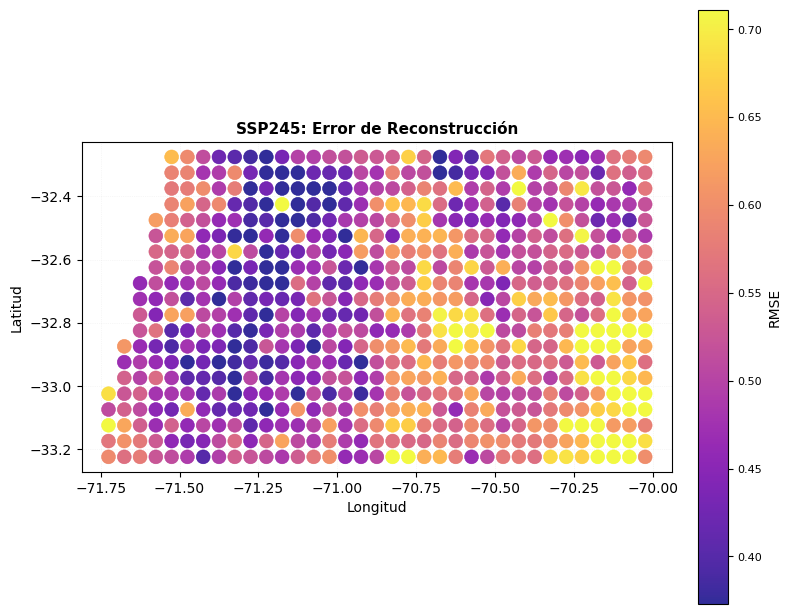

✓ Gráfico tesis SSP370 guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/spatial_reconstruction_ssp370_thesis.png


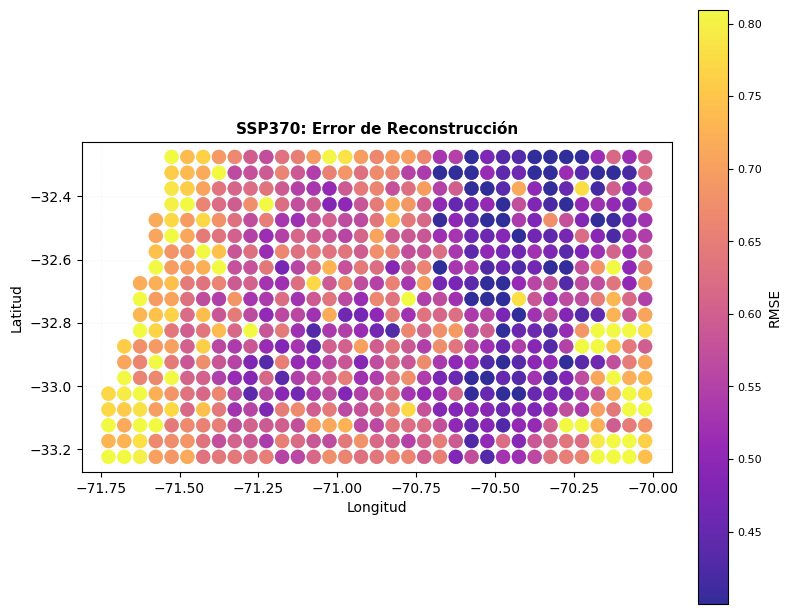

✓ Gráfico tesis SSP585 guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/spatial_reconstruction_ssp585_thesis.png


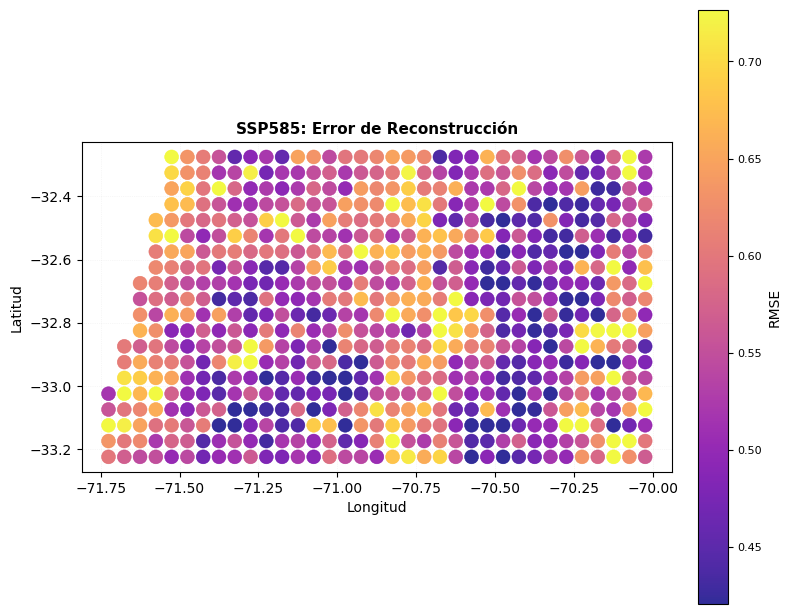

In [63]:

print("\n" + "="*80)
print("FIGURA PARA TESIS: Reconstrucción SSP (formato compacto)")
print("="*80 + "\n")

# Generar una figura compacta por SSP para la tesis (ancho 0.42\textwidth)
for ssp in ssps:
    fig, ax = plt.subplots(figsize=(8, 7))
    
    X_orig = models_recon[ssp]["orig"]
    X_recon = models_recon[ssp]["VAE"]  # VAE para la tesis
    
    error_agg = np.sqrt(np.mean((X_orig - X_recon) ** 2, axis=1))
    
    scatter = ax.scatter(lon_vals, lat_vals, c=error_agg, cmap='plasma', 
                        s=100, alpha=0.85, edgecolors='face', linewidth=0.4,
                        vmin=np.percentile(error_agg, 5), 
                        vmax=np.percentile(error_agg, 95))
    
    # Barra de color compacta
    cbar = plt.colorbar(scatter, ax=ax, label='RMSE', fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)
    
    ax.set_xlabel('Longitud', fontsize=10)
    ax.set_ylabel('Latitud', fontsize=10)
    ax.set_title(f'SSP{ssp}: Error de Reconstrucción', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.2, linestyle=':', linewidth=0.5)
    ax.set_aspect('equal')
    
    plt.tight_layout()
    
    output_path = PLOTS_DIR / f"spatial_reconstruction_ssp{ssp}_thesis.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Gráfico tesis SSP{ssp} guardado: {output_path}")
    plt.show()


In [52]:
print("DIAGNÓSTICO DE COORDENADAS:")
print()
print(f"coords_df shape: {coords_df.shape}")
print(f"coords_df columns: {coords_df.columns.tolist()}")
print(f"coords_df head:\n{coords_df.head()}")
print()
print(f"lat_grid shape: {lat_grid.shape}")
print(f"lon_grid shape: {lon_grid.shape}")
print()
print(f"N_PER_SCENARIO: {N_PER_SCENARIO}")
print(f"len(lat_grid.flatten()): {len(lat_grid.flatten())}")


DIAGNÓSTICO DE COORDENADAS:

coords_df shape: (661, 3)
coords_df columns: ['lat', 'lon', 'pixel_id']
coords_df head:
      lat     lon  pixel_id
0 -32.975 -70.025         0
1 -32.875 -71.025         1
2 -32.275 -70.575         2
3 -32.825 -70.875         3
4 -32.525 -70.175         4

lat_grid shape: (24, 42)
lon_grid shape: (24, 42)

N_PER_SCENARIO: 661
len(lat_grid.flatten()): 1008



PLOT PARA TESIS: Distribución del Error por Escenario (Violinplot)

✓ Gráfico guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/reconstruction_error_by_scenario.png
✓ Copia en: /home/aninotna/magister/tesis/justh2_pipeline/plots/reconstruction_error_by_scenario.png
✓ Gráfico guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/reconstruction_error_by_scenario.png
✓ Copia en: /home/aninotna/magister/tesis/justh2_pipeline/plots/reconstruction_error_by_scenario.png


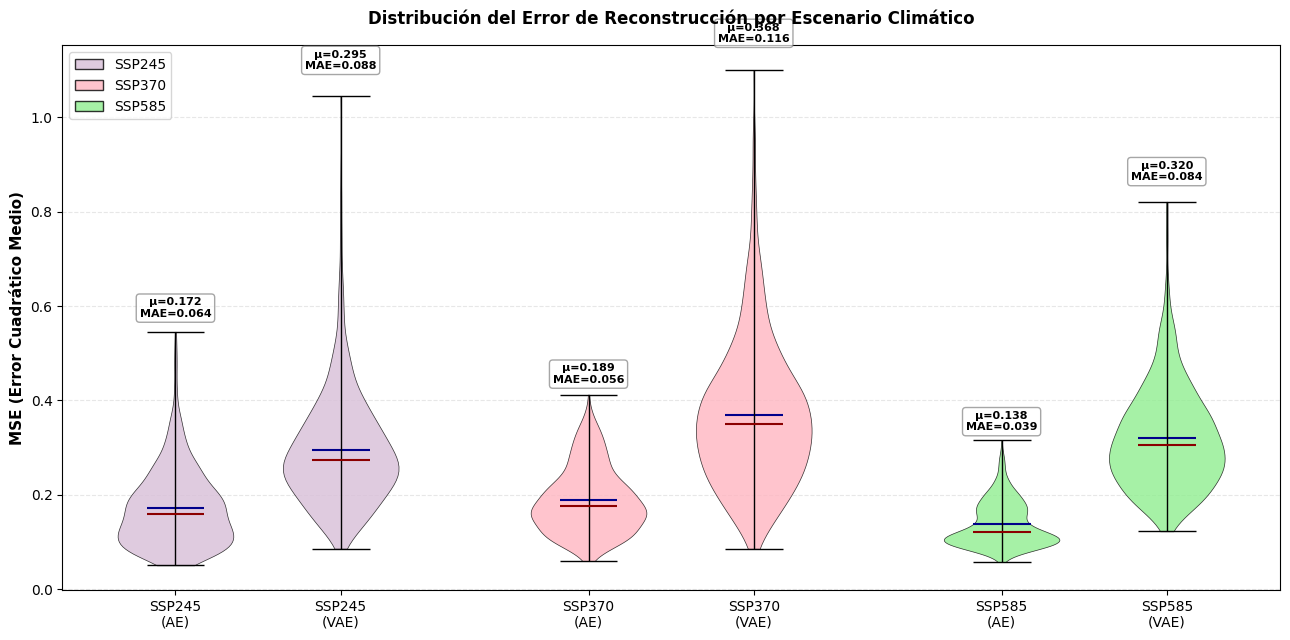


Estadísticas por modelo y escenario:
SSP245:
  AE  → μ=0.17217 | MAE=0.06413 | med=0.15950
  VAE → μ=0.29484 | MAE=0.08801 | med=0.27298
SSP370:
  AE  → μ=0.18916 | MAE=0.05633 | med=0.17679
  VAE → μ=0.36847 | MAE=0.11615 | med=0.34957
SSP585:
  AE  → μ=0.13795 | MAE=0.03904 | med=0.12219
  VAE → μ=0.32019 | MAE=0.08431 | med=0.30581


In [69]:

print("\n" + "="*80)
print("PLOT PARA TESIS: Distribución del Error por Escenario (Violinplot)")
print("="*80 + "\n")

# Calcular errores MSE por píxel para todos los SSP
errors_data = {}

for ssp in ["245", "370", "585"]:
    X_orig = models_recon[ssp]["orig"]
    X_recon_ae = models_recon[ssp]["AE"]
    X_recon_vae = models_recon[ssp]["VAE"]
    
    mse_ae = np.mean((X_orig - X_recon_ae) ** 2, axis=1)
    mse_vae = np.mean((X_orig - X_recon_vae) ** 2, axis=1)
    
    errors_data[f"SSP{ssp}"] = {"AE": mse_ae, "VAE": mse_vae}

# Crear figura con violinplots - colores pastel
fig, ax = plt.subplots(figsize=(13, 6.5))

data_for_plot = []
labels_for_plot = []
positions = []

# Colores pastel: morado, rosado, verde
color_pastel_morado = "#D8BFD8"  # Thistle (morado pastel)
color_pastel_rosado = "#FFB6C1"  # Light pink (rosado pastel)
color_pastel_verde = "#90EE90"   # Light green (verde pastel)
colors_palette = [color_pastel_morado, color_pastel_rosado, color_pastel_verde]

pos = 0
stats_dict = {}
for ssp in ["SSP245", "SSP370", "SSP585"]:
    # AE
    data_for_plot.append(errors_data[ssp]["AE"])
    labels_for_plot.append(f"{ssp}\n(AE)")
    positions.append(pos)
    stats_dict[pos] = {
        "mean": np.mean(errors_data[ssp]["AE"]),
        "mae": np.mean(np.abs(errors_data[ssp]["AE"] - np.mean(errors_data[ssp]["AE"])))
    }
    pos += 1
    
    # VAE
    data_for_plot.append(errors_data[ssp]["VAE"])
    labels_for_plot.append(f"{ssp}\n(VAE)")
    positions.append(pos)
    stats_dict[pos] = {
        "mean": np.mean(errors_data[ssp]["VAE"]),
        "mae": np.mean(np.abs(errors_data[ssp]["VAE"] - np.mean(errors_data[ssp]["VAE"])))
    }
    pos += 1.5

# Crear violinplot
parts = ax.violinplot(data_for_plot, positions=positions, widths=0.7, 
                       showmeans=True, showmedians=True)

# Colorear los violines - alternar colores por SSP
color_cycle = []
for i in range(3):
    color_cycle.extend([colors_palette[i], colors_palette[i]])

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(color_cycle[i])
    pc.set_alpha(0.8)
    pc.set_edgecolor('black')
    pc.set_linewidth(0.5)

# Mejorar apariencia de los componentes del violinplot
for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians', 'cmeans'):
    if partname in parts:
        if partname == 'cmedians':
            parts[partname].set_edgecolor('darkred')
            parts[partname].set_linewidth(1.5)
        elif partname == 'cmeans':
            parts[partname].set_edgecolor('darkblue')
            parts[partname].set_linewidth(1.5)
        else:
            parts[partname].set_edgecolor('black')
            parts[partname].set_linewidth(1)

# Agregar etiquetas de μ y MAE en cada violín
for pos in positions:
    stats = stats_dict[pos]
    mean_val = stats["mean"]
    mae_val = stats["mae"]
    
    # Calcular altura máxima aproximada del violín para posicionar el texto
    violin_data = data_for_plot[positions.index(pos)]
    max_val = np.max(violin_data)
    
    # Mostrar μ y MAE encima de cada violín
    ax.text(pos, max_val * 1.05, f"μ={mean_val:.3f}\nMAE={mae_val:.3f}", 
            ha='center', va='bottom', fontsize=8, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='gray'))

ax.set_xticks(positions)
ax.set_xticklabels(labels_for_plot, fontsize=10)
ax.set_ylabel('MSE (Error Cuadrático Medio)', fontsize=11, fontweight='bold')
ax.set_title('Distribución del Error de Reconstrucción por Escenario Climático', 
             fontsize=12, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors_palette[0], alpha=0.8, edgecolor='black', label='SSP245'),
    Patch(facecolor=colors_palette[1], alpha=0.8, edgecolor='black', label='SSP370'),
    Patch(facecolor=colors_palette[2], alpha=0.8, edgecolor='black', label='SSP585'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.tight_layout()

output_path = PLOTS_DIR / "reconstruction_error_by_scenario.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ Gráfico guardado: {output_path}")

import shutil
shutil.copy(str(output_path), str(Path(BASE_DIR) / "plots" / "reconstruction_error_by_scenario.png"))
print(f"✓ Copia en: {Path(BASE_DIR) / 'plots' / 'reconstruction_error_by_scenario.png'}")

plt.show()

print("\nEstadísticas por modelo y escenario:")
for ssp in ["SSP245", "SSP370", "SSP585"]:
    ae_mean = np.mean(errors_data[ssp]["AE"])
    ae_med = np.median(errors_data[ssp]["AE"])
    ae_mae = np.mean(np.abs(errors_data[ssp]["AE"] - ae_mean))
    
    vae_mean = np.mean(errors_data[ssp]["VAE"])
    vae_med = np.median(errors_data[ssp]["VAE"])
    vae_mae = np.mean(np.abs(errors_data[ssp]["VAE"] - vae_mean))
    
    print(f"{ssp}:")
    print(f"  AE  → μ={ae_mean:.5f} | MAE={ae_mae:.5f} | med={ae_med:.5f}")
    print(f"  VAE → μ={vae_mean:.5f} | MAE={vae_mae:.5f} | med={vae_med:.5f}")
